## 第5章: 在无标签数据上进行预训练

In [1]:
from importlib.metadata import version

pkgs = ["matplotlib", 
        "numpy", 
        "tiktoken", 
        "torch",
        "tensorflow" 
       ]
for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.10.8
numpy version: 2.4.0
tiktoken version: 0.12.0
torch version: 2.9.1
tensorflow version: 2.20.0


在这一章中，我们将实现用于预训练大语言模型的训练循环，并编写基础的模型评估代码，用来检查模型训练后的效果与质量。章节最后，我们还会把 OpenAI 公开提供的预训练权重加载到我们实现的模型中，以便直接在已有能力的基础上继续使用或进行后续任务。

### 5.1 评估文本生成模型

#### 5.1.1 使用GPT来生成文本

我们将复用上一章的代码来初始化一个 GPT 模型，确保模型结构与参数配置按既定方式正确创建，为后续训练与评估做好准备。

In [2]:
import torch
from previous_chapters import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,   
    "context_length": 256, 
    "emb_dim": 768,        
    "n_heads": 12,         
    "n_layers": 12,      
    "drop_rate": 0.1,      
    "qkv_bias": False     
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();  

上面我们把`dropout`设为 0.1，但现在不少大模型训练时其实会选择不使用`dropout`，因为在大规模数据和训练策略下，`dropout`带来的收益往往不再明显。现代大模型在注意力层里生成query、key、value 的`nn.Linear`通常也不再使用`bias`向量（这点和早期 GPT 模型不同），实现方式就是把配置里的`qkv_bias`设为`False`。

另外，我们把上下文长度`context_length`降到256个token来降低训练的计算资源需求，而原始的1.24 亿参数GPT-2使用的是1024个 token，这样做的主要目的是可以在普通笔记本上跟着跑通示例.

接下来我们会继续使用上一章的`generate_text_simple`函数来生成文本，验证模型是否能按给定的提示词输出内容。同时，我们会额外定义两个便捷函数`text_to_token_ids`和`token_ids_to_text`，用于在文本和 token ID 之间来回转换，这样在本章的训练、评估和生成流程中处理输入输出会更统一、更省事。

In [3]:
import tiktoken
from previous_chapters import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    # tokenizer.encode 会把文本切分成 token，并返回对应的 token id 列表（Python list[int]）
    # allowed_special 允许在文本中出现特殊标记（例如 <|endoftext|>），否则遇到这些标记可能会报错或被当作普通文本处理
    
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) 
    # 把 token id 列表转成 PyTorch 张量，形状是 [seq_len]
    # torch.tensor(encoded) -> 1D 张量，例如 [15496, 1234, ...]
    # unsqueeze(0) 在最前面增加一个 batch 维度，变成 [1, seq_len]
    # 这么做是因为大多数模型的输入都要求带 batch 维，即使只生成一条样本也要写成 batch=1
    
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) 
    # token_ids 通常是 [1, seq_len]（带 batch 维）
    # squeeze(0) 去掉 batch 维，变成 [seq_len]
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
    # 作为生成任务的提示词（prompt），模型会在这个前缀基础上继续往后写

tokenizer = tiktoken.get_encoding("gpt2")
    # 获取 GPT-2 对应的 BPE 分词器（tiktoken 内置编码）
    # 这样编码/解码会与 GPT-2 家族模型的 token 体系一致

token_ids = generate_text_simple(
    model=model, # 已初始化并可推理的 GPT 模型实例
    
    idx=text_to_token_ids(start_context, tokenizer),  # idx 是模型的输入 token id 序列，这里把 start_context 编码成张量后传入
                                                      # 形状通常是 [1, seq_len]
    
    max_new_tokens=10,  # max_new_tokens 表示在原始输入后面最多再生成多少个新 token
                        # 注意：token 不等于英文单词，可能是词的一部分或多个字符
    
    context_size=GPT_CONFIG_124M["context_length"] # context_size 是模型的上下文窗口大小（最多能“看见”的 token 数）
                                                   # 生成时通常会用它来裁剪输入序列，避免长度超过模型限制
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


从上面的输出可以看出，模型还没有经过训练，所以生成的文本质量并不好。关键问题是，**我们如何把“文本好不好”这种主观感受用一个可量化的数值表示出来，才能在训练过程中持续跟踪模型是否在变好。** 接下来会引入用于评估生成结果的指标，重点是计算一个**损失值（loss）**，用它来衡量训练进度并指导参数更新。后续讲大模型微调的章节还会进一步介绍更多评估模型质量的方法，让质量衡量不只停留在 loss 上。

#### 5.1.2 计算文本生成损失

假设我们有一个inputs张量，其中每一行是一条训练样本的token ID序列，这里一共有两条样本。与inputs相对应，targets保存的是我们希望模型在每个位置上预测出来的“正确 token ID”。

需要注意的是，targets实际上就是把inputs整体向左或向右平移一位得到的，也就是“用当前位置的 token 去预测下一个 token”。

In [4]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

把 inputs 输入模型后，我们会得到对应的 logits 张量，这里一共有两条输入样本，每条样本包含 3 个 token，因此 logits 会为每个样本的每个位置输出一组预测结果。每个位置的预测都是一个 50,257 维的向量，这个维度等于词表大小，表示模型对“下一个 token 可能是谁”的打分。再对 logits 施加 softmax，就能把这些打分转换成同样形状的概率分布张量，每一维对应词表中某个 token 的概率分数。

In [5]:
with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1) 
print(probas.shape) 

torch.Size([2, 3, 50257])


如上一章所说，我们可以对概率分布使用`argmax`，把每个位置上“概率最高的那个词”转换成预测的token ID。因为`softmax`会为每个位置输出一个50,257维的向量，代表词表中每个token的概率，而`argmax`做的就是在这个向量里找到最大概率所在的下标，这个下标就是该位置预测出来的token ID。

由于我们有两个输入样本（batch 中的两条序列），并且每条序列包含3个token，所以最终会得到一个2×3的预测token ID矩阵，也就是每个样本的每个位置各对应一个预测出来的token ID。

In [6]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)

Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


如果把这些预测token解码回文本，会发现它们与我们期望模型输出的结果差异很大，而我们真正希望模型预测出来的是targets里的那些目标 token。

In [7]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armed heNetflix


这主要是因为模型还没有训练过。要让模型学会正确预测，我们首先需要一个方法来衡量它当前的输出与正确答案（targets）之间差得有多远。

与目标 token ID 所对应的那些概率值如下所示，也就是在每个位置上取出模型对正确目标 token 分配的概率分数。

In [8]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

#  从 probas 里取出“每个位置上，模型对正确目标 token（targets）给出的概率”，分别看两条样本的结果

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4541e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


我们希望把这些对应目标 token 的概率都尽可能拉高，让它们接近 1，从而表示模型在每个位置都更倾向于输出正确答案。在数学优化里，直接最大化概率本身不如最大化概率的对数来得方便和稳定，因此训练时通常会把概率先取对数再进行优化。

In [9]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


接下来我们计算平均值。

In [10]:
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


我们的目标是通过优化模型权重，让这些目标 token 的平均对数概率尽可能大。因为取了对数，理论上的最大值是 0（对应概率为 1），而我们当前的数值还远小于 0，说明模型距离“稳定预测正确”还有很大差距。

在深度学习里，通常不会直接去最大化平均对数概率，而是遵循约定把它取负号，转成一个需要最小化的目标函数。也就是说，我们原本希望把 -10.7722 这种值尽量往 0 拉近，实际训练时会最小化它的相反数 10.7722，让这个数尽量接近 0。这个对数概率取负后的数值在深度学习中也被称为**交叉熵损失（cross-entropy loss）**。

In [11]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


PyTorch 已经内置了`cross_entropy`函数，可以直接完成前面提到的这些计算步骤，用它就能把模型输出和目标 token 转换成交叉熵损失值。

我们通常需要先把这些张量在 batch 维度上合并并展平，也就是把多个样本和多个位置的预测统一拉成一组连续的数据，方便一次性计算整体的损失值。

In [12]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


需要注意的是，targets 里存的是目标 token 的 ID，它们同时也是 logits 张量中我们希望“概率尽量高”的那些位置索引。PyTorch 的 `cross_entropy`会在内部自动完成`softmax`以及对数概率的计算，并且只针对这些目标索引对应的`logits`来计算并汇总损失，因此我们不需要手动先算概率再取对数。

In [13]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


与交叉熵损失密切相关的一个概念是大语言模型的**困惑度（perplexity）**。困惑度的计算很简单，就是对交叉熵损失取指数，也就是困惑度等于交叉熵损失的 exp。

In [14]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(48725.8203)


困惑度通常被认为更直观，因为它可以理解为模型在每一步“相当于在多少个候选词或 token 之间犹豫不决”，也就是一种有效词表规模的感觉（例如上面的例子大约相当于 48,725 个词或 token）。换句话说，困惑度衡量的是模型预测出来的概率分布与数据集中真实词分布的匹配程度。和损失一样，困惑度越低，说明模型的预测越接近真实分布，整体效果也越好。

#### 5.1.3 计算训练集和验证集的损失

我们这里会用一个非常小的数据集来训练大语言模型，实际上只有一篇短篇故事。这样做主要是为了让你在没有合适GPU的普通笔记本上也能在几分钟内跑完代码，并且训练能在分钟级结束而不是动辄几周，更适合教学演示。

优先从本地读取文本文件，如果本地还没有，就从 GitHub 的原始链接下载一份并保存到当前目录。这样做的好处是第一次运行会自动拉取数据，之后反复运行就直接用本地文件，既省时间也更稳定。

In [15]:
import os
import requests

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    text_data = response.text
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

我们可以做一个快速检查：分别打印文本开头和结尾的 99 个字符，确认文件是否成功加载且内容没有异常。

In [16]:
print(text_data[:99])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [17]:
print(text_data[-99:])

it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."


In [18]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


这份文本只有 5,145 个 token，用来训练大语言模型其实非常短，但它的目标是教学演示，便于你快速跑通完整流程；而且我们后面也会加载预训练权重，所以不会只依赖这点数据来获得实际可用的模型能力。

接下来我们会把数据集划分为训练集和验证集，并复用第2章实现的数据加载器来构建批数据，供大模型训练使用。为了便于画图说明，下图假设 max_length=6，但在实际训练的训练集加载器里，我们会把`max_length`设为模型支持的上下文长度`context_length`，这样每个样本的序列长度就与模型的输入窗口一致。图中为了简化只展示了输入token；由于我们的训练目标是“根据当前token预测下一个token”，所以 targets与这些输入几乎相同，只是整体向后错开一位。

In [19]:
from previous_chapters import create_dataloader_v1

train_ratio = 0.90 # 按 90%/10% 将原始文本切分为训练集与验证集（用来监控是否过拟合）
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"], # 每条序列长度 = 模型支持的上下文长度
    stride=GPT_CONFIG_124M["context_length"],     # 每次滑动步长 = 上下文长度 => 样本之间几乎不重叠
    drop_last=True,  # 训练时丢弃最后一个不满 batch 的小批次，避免 batch 形状不一致
    shuffle=True,    # 训练集打乱顺序，减少模型按固定顺序“记住文本位置”的风险
    num_workers=0    # 笔记本/Windows 环境常设为 0，避免多进程带来的兼容性问题
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,  # 验证时通常不丢数据，最后一个不满 batch 的也参与评估
    shuffle=False,    # 验证集不打乱，保证评估稳定可复现
    num_workers=0
)

首先用`train_ratio=0.90`把`text_data`的前90%作为训练集、后10%作为验证集，验证集不参与参数更新，只用来观察模型在“没见过的文本片段”上的表现，从而判断训练是否真的在提升泛化能力，还是只是在背训练集。

`create_dataloader_v1`会把长文本按滑动窗口切成一段段长度固定的序列，这里把`max_length`设成模型配置里的 `context_length`，意味着每条样本序列都刚好等于模型能处理的上下文窗口大小。`stride`也设成同样的值，表示窗口每次向前移动一个完整上下文长度，样本之间基本不重叠，这样切片数量更少、训练更省资源

训练集的`shuffle=True`会在每个epoch打乱样本顺序，避免模型总按固定顺序看到相邻片段，降低学习过程中的偏差；同时 `drop_last=True`会丢弃最后一个不足`batch_size`的小批次，保证每个batch的形状一致，训练过程更稳定。

验证集则相反：`shuffle=False`保证评估顺序稳定可复现，`drop_last=False`让最后不满batch的数据也能参与评估，尽量把验证集信息用全。整体上，这样你就得到了两个loader：`train_loader`用于训练更新参数，`val_loader`用于定期计算损失/困惑度来跟踪模型质量变化。

In [20]:
if total_tokens * (train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the training loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "increase the `training_ratio`")

if total_tokens * (1-train_ratio) < GPT_CONFIG_124M["context_length"]:
    print("Not enough tokens for the validation loader. "
          "Try to lower the `GPT_CONFIG_124M['context_length']` or "
          "decrease the `training_ratio`")

如果`total_tokens * train_ratio`小于`GPT_CONFIG_124M["context_length"]`，就会提示训练集 token 数不够用来构建训练数据加载器，建议把`GPT_CONFIG_124M['context_length']`调小，或者把`training_ratio`调大。

如果`total_tokens * (1 - train_ratio)`小于`GPT_CONFIG_124M["context_length"]`，就会提示验证集token数不够用来构建验证数据加载器，建议把`GPT_CONFIG_124M['context_length']`调小，或者把`training_ratio`调小（也就是给验证集分配更多比例）。

我们这里使用较小的 batch size，一方面是为了降低计算资源需求，另一方面也是因为数据集本身就很小，没有必要用很大的批量。作为对比，Llama 2 7B 这类大模型的训练 batch size 通常非常大，例如它使用过 1024 的 batch size。

我们还可以做一个可选的检查，用来确认数据是否被正确加载和切分

In [21]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


将遍历训练集和验证集的DataLoader，把每个batch的输入张量x和目标张量y的形状打印出来，用来快速确认数据加载是否正常、batch 维度是否符合预期。

In [22]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


这段代码用来统计训练集和验证集中一共包含多少个token。它遍历`train_loader`和`val_loader`的每个batch，用 `input_batch.numel()`计算输入张量里元素的总数（也就是batch内token的数量），分别累加得到`train_tokens`和`val_tokens`，最后打印训练token数、验证token数以及两者之和，方便你确认数据规模和训练会用到的总token量。

接下来我们会实现一个工具函数，用来计算某个 batch 的交叉熵损失。然后再实现第二个工具函数，用于在数据加载器中按用户指定的 batch 数量计算并汇总损失，方便快速评估训练集或验证集的整体表现。

In [23]:
def calc_loss_batch(input_batch, target_batch, model, device):
    # 将输入和目标移动到同一个设备（CPU/GPU），避免设备不一致报错
    
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    # 前向计算得到 logits，形状通常为 [batch_size, seq_len, vocab_size]
    
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    # 交叉熵要求输入形状为 [N, C]、目标形状为 [N]
    # 这里把 batch 和 seq_len 两个维度展平成 N = batch_size * seq_len
    
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    # 空 loader 直接返回 NaN，避免除以 0 或误导性结果
        
    elif num_batches is None:
        num_batches = len(data_loader)
    # 默认遍历整个 loader；也可以只算前 num_batches 个 batch（用于快速评估/调试）
    
    else:
        num_batches = min(num_batches, len(data_loader))
    # 防止用户传入的 num_batches 超过 loader 实际 batch 数
    
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
    # 累加每个 batch 的 loss（用 loss.item() 取出 Python 数值，避免把计算图保留在内存里）
        
        else:
            break
    return total_loss / num_batches

如果你的机器有支持 CUDA 的 GPU，这个大模型会在 GPU 上训练，而且不需要改动任何代码。通过设置 device，我们确保输入数据会被移动到与模型相同的设备上，从而避免设备不一致导致的错误，并正确使用 GPU 加速。

In [24]:
if torch.cuda.is_available():
    device = torch.device("cuda")  # 优先使用 NVIDIA GPU（CUDA）
    
elif torch.backends.mps.is_available():
    # Apple Silicon（M1/M2/M3）可用时尝试使用 MPS 加速
    # 这里检查 PyTorch 版本是为了避免旧版本 MPS 结果不稳定
    
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")  # 版本太旧则退回 CPU
else:
    device = torch.device("cpu")      # 没有 GPU 加速就用 CPU

print(f"Using {device} device.")

model.to(device) # 把模型参数移动到同一设备；nn.Module 会原地更新，不需要重新赋值

torch.manual_seed(123) 

with torch.no_grad():  # 这里只做评估，不做训练；关闭梯度可节省显存/内存并加快计算
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Using mps device.
Training loss: 10.987583054436577
Validation loss: 10.98110580444336


### 5.2 训练大语言模型

这节会先聚焦于一个尽量简单、清晰的训练函数。

In [25]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # 记录训练/验证 loss 的变化，以及累计“看过的 token 数”（常用作训练进度的横轴）
    
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):  # 按 epoch 进行多轮训练
        model.train()                # 进入训练模式（启用 dropout、layernorm 等训练行为）
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()   # 清空上一轮 batch 的梯度，避免梯度累积
            loss = calc_loss_batch(input_batch, target_batch, model, device)  # 前向 + 交叉熵 loss
            loss.backward()   # 反向传播，计算每个参数的梯度
            optimizer.step()  # 用优化器根据梯度更新模型参数
            
            tokens_seen += input_batch.numel()
            global_step += 1  # 统计训练进度：累计处理过多少个 token（batch_size * seq_len）
            
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")
             # 按固定频率做一次快速评估（只评估 eval_iter 个 batch，节省时间）

        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()  # 进入评估模式（关闭 dropout 等随机性，保证评估稳定）
    
    with torch.no_grad(): # 评估不需要梯度，节省显存/内存并加速
                          # 只用前 eval_iter 个 batch 估算平均 loss，速度快但足够用于训练过程的趋势监控
        
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
        
    model.train()  # 评估结束切回训练模式，继续后面的参数更新
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()  # 生成时用评估模式，避免 dropout 影响输出稳定性
    
    context_size = model.pos_emb.weight.shape[0]  # 从位置嵌入长度读取模型支持的上下文窗口
    encoded = text_to_token_ids(start_context, tokenizer).to(device) # prompt 编码并放到同一设备
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )    # 基于 start_context 继续生成 50 个新 token
        
    decoded_text = token_ids_to_text(token_ids, tokenizer)  # 解码成可读文本
    print(decoded_text.replace("\n", " "))  
    model.train()

`train_model_simple`是主入口，它按`num_epochs`反复遍历训练集，每个batch都执行标准三步：`zero_grad`清空旧梯度，`calc_loss_batch`前向计算交叉熵损失，`backward`反向传播得到梯度，`step`用优化器更新参数。这里额外维护了`tokens_seen`，它用`input_batch.numel()`统计累计处理过多少个token，比“训练了多少步”更能反映训练规模，因为token数才是大模型训练常用的进度单位。

训练过程中不会每一步都做完整评估，因为代价太高，所以用`eval_freq`控制评估频率，用`eval_iter`控制每次评估只跑前多少个batch 来做近似。`evaluate_model`的关键点是把模型切到`eval()` 并用`torch.no_grad()`，这样`dropout`等随机行为会关闭，且不建立计算图，评估更稳定也更省资源；评估结束再切回`train()`，保证后续训练行为正常。训练和验证的`loss`都被记录下来，并且把当时的 `tokens_seen`一并保存，后面画曲线时就能用`token`数作为横轴对齐比较。

每个epoch结束后调用`generate_and_print_sample`生成一段样例文本，这是训练过程里最直观的质量检查。它从模型的位置嵌入 `pos_emb`读取上下文窗口大小，保证生成时的`context_size`与模型配置一致；随后把`start_context`编码成token并移动到同一设备，调用`generate_text_simple`续写一定数量的新token，再解码成文本打印出来。这里同样用`eval()`和`no_grad()`，避免生成时引入随机性和额外开销，最后再切回`train()`继续训练。整体思路就是：`loss`用来量化进度，`sample`用来感知输出是否在变得更合理，两者结合能更快发现训练是否真的在朝正确方向收敛。

In [26]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW( # AdamW 优化器：训练大模型常用，带 weight_decay 的正则化更稳定
    model.parameters(), 
    lr=0.0004, # 学习率：决定每次参数更新步幅
    weight_decay=0.1 # 权重衰减：抑制权重过大，降低过拟合风险
)

num_epochs = 10  # 训练轮数：完整遍历训练集 10 次

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs,  # 训练总轮数
    eval_freq=5,  # 每训练 5 个 step 就做一次快速评估
    eval_iter=5,  # 每次评估只跑 5 个 batch，用于快速估算趋势
    start_context="Every effort moves you",  # 每个 epoch 后用这句 prompt 生成示例文本观察效果
    tokenizer=tokenizer # 用于 prompt 的编码/解码
)

Ep 1 (Step 000000): Train loss 9.817, Val loss 9.924
Ep 1 (Step 000005): Train loss 8.066, Val loss 8.332
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.619, Val loss 7.042
Ep 2 (Step 000015): Train loss 6.046, Val loss 6.596
Every effort moves you, and,, and, and,,,,, and, and,,,,,,,,,,, and,, the,, the, and,, and,,, the, and,,,,,,
Ep 3 (Step 000020): Train loss 5.524, Val loss 6.508
Ep 3 (Step 000025): Train loss 5.369, Val loss 6.378
Every effort moves you, and to the of the of the picture. Gis.                                     
Ep 4 (Step 000030): Train loss 4.830, Val loss 6.263
Ep 4 (Step 000035): Train loss 4.586, Val loss 6.285
Every effort moves you of the "I the picture.                    "I"I the picture"I had the picture"I the picture and I had been the picture of
Ep 5 (Step 000040): Train loss 3.879, Val loss 6.130
Every effort moves you know he had been his pictures, and I felt it's by his last word.          

需要注意的是，你在自己电脑上跑出来的 loss 数值可能会和示例略有不同，只要整体量级接近就不用担心，比如训练集 loss 低于 1、验证集 loss 低于 7 这一类结果通常都算合理。出现小差异的常见原因是 GPU 硬件不同、CUDA 版本不同，或者你使用的 PyTorch 版本更高，内部实现细节有轻微变化。

即使你是在 CPU 上运行，也可能观察到一些差异，其中一个可能原因是`nn.Dropout`在不同操作系统上的行为会有细微区别，这与 PyTorch 的编译方式有关。

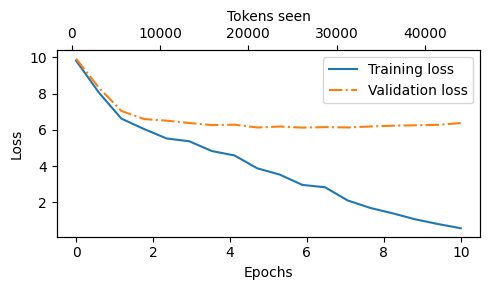

In [27]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  

    ax2 = ax1.twiny()  
    ax2.plot(tokens_seen, train_losses, alpha=0)  
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

从上面的结果可以看出，模型一开始只能生成一些难以理解的词串，但训练到后期已经能写出语法上基本正确、读起来更连贯的句子。不过从训练集和验证集的 loss 变化也能看出模型开始过拟合了，也就是训练集表现持续变好，但验证集并没有同步改善甚至变差。如果你去检查训练末期生成的部分段落，会发现其中有些内容会与训练集原文完全一致，这说明模型在这种设置下更多是在“背诵”训练数据，而不是学到可泛化的语言规律。

后面我们会介绍一些解码策略，可以在一定程度上缓解这种记忆式输出的问题。需要强调的是，这里的过拟合主要是因为训练集极其小，而且我们对同一份数据重复训练了很多轮；本节训练的核心目的在于教学演示，重点是验证模型确实能够学会生成更连贯的文本。真正要获得实用能力，不会用这种方式在少量数据上训练很多轮，我们后面会直接加载预训练权重，而不是花几周或几个月在昂贵硬件上从零训练。

### 5.3 控制随机性的解码策略

在这一节里，我们的目的不是“再训练模型”，而是把训练好的模型当成一个固定的概率预测器，专注研究它在推理时如何把“下一步每个 token 的概率分布”变成最终输出文本。

像我们上面训练的这种参数规模较小的GPT模型，在推理阶段的计算成本相对低，因此即使你训练时用过GPU，推理时通常也不一定需要GPU。我们可以继续使用上一章的`generate_text_simple`函数，按token一步步生成新文本。

In [28]:
inference_device = torch.device("cpu")

model.to(inference_device)
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model, # 已训练好的模型
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device), # prompt 编码成 token 并放到推理设备
    max_new_tokens=25, # 在 prompt 后最多继续生成 25 个新 token
    context_size=GPT_CONFIG_124M["context_length"] # 生成时使用模型支持的上下文长度，必要时会裁剪输入
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




即使我们把上面的`generate_text_simple`反复执行多次，大模型也总会生成完全相同的输出。接下来我们会引入两种用于修改 `generate_text_simple`的解码策略：**温度缩放（temperature scaling)** 和**top-k 采样（top-k sampling）**。它们可以让模型在生成时调节随机性与多样性，从而控制输出是更稳定还是更丰富。

#### 5.3.1 温度缩放

之前我们用`torch.argmax`总是选择概率最高的token作为下一个token，因此输出是确定且固定的。为了让结果更有变化，我们可以用 `torch.multinomial(probs, num_samples=1)` 从概率分布中随机采样下一个token。这样每个token被选中的机会就与它在输入概率张量中的概率值成正比，概率越高被抽到的可能性越大。

下面我们用一个非常小的词表做示意，简单回顾一下在生成过程中“如何产生下一个 token”。

In [29]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v: k for k, v in vocab.items()}
# 反向映射：token_id -> token 字符串，方便把预测结果还原成词

next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)
# 假设输入是 "every effort moves you"，模型会输出“下一个 token”的 logits（未归一化分数）

probas = torch.softmax(next_token_logits, dim=0) # 把 logits 转成概率分布（所有概率加起来等于 1）
next_token_id = torch.argmax(probas).item() # 贪心解码：选概率最大的那个 token id（结果确定、不随机）

print(inverse_vocab[next_token_id])

forward


In [30]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


我们不再用`torch.argmax`直接选出概率最高的token，而是用`torch.multinomial(probas, num_samples=1)` 从`softmax`得到的概率分布中进行采样，把“选下一个token”的过程变成随机抽样。为了直观说明效果，我们可以用原始的`softmax`概率重复采样 1,000 次，观察各个token被抽到的频率分布会是什么样。

In [31]:
def print_sampled_tokens(probas):
    torch.manual_seed(123) 
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    # 从概率分布 probas 中重复采样 1000 次，每次返回一个 token id
    
    sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
    # 统计每个 token id 被采样到的次数（minlength 保证所有词表位置都有计数）
    
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


我们可以用一种叫 **“温度缩放”** 的方法来调节概率分布以及选token的过程。所谓温度缩放，其实就是把logits除以一个大于0的数。温度大于1时，经过`softmax`后的概率会更均匀，采样更随机、输出更多样；温度小于1时，经过`softmax`后的分布会更尖锐，模型更偏向少数高概率token，采样更确定、输出更稳定。

In [32]:
def softmax_with_temperature(logits, temperature):
    # 温度缩放：先把 logits 除以 temperature，再做 softmax 得到概率分布
    # temperature < 1 会让分布更尖锐（更确定），temperature > 1 会让分布更平滑（更随机）
    
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

temperatures = [1, 0.1, 5]  # 选择三个温度做对比：1 表示不改变；0.1 更尖锐；5 更平滑
                            # 原始、提高置信度、降低置信度

scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]
    # 分别计算不同温度下的概率分布，便于观察温度对随机性/多样性的影响

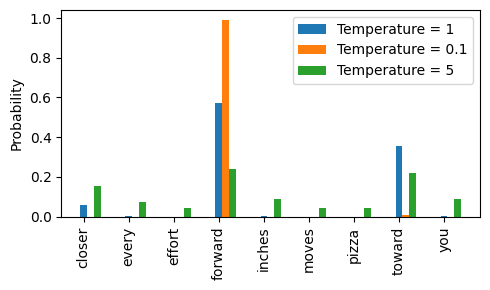

In [33]:
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

可以看到，当温度设为 0.1 时，缩放后的概率分布会变得更尖锐，效果接近`torch.argmax`，模型几乎总是会选中概率最高的那个词作为下一步输出。

In [34]:
print_sampled_tokens(scaled_probas[1])

0 x closer
0 x every
0 x effort
985 x forward
0 x inches
0 x moves
0 x pizza
15 x toward
0 x you


当温度设为 5 时，缩放后的概率会更接近均匀分布，也就是各个候选 token 的差距被拉小，采样时更容易出现多样化的选择。

In [35]:
print_sampled_tokens(scaled_probas[2])

165 x closer
75 x every
42 x effort
239 x forward
71 x inches
46 x moves
32 x pizza
227 x toward
103 x you


假设大模型的输入是 “every effort moves you”，用上面的采样方式有时会生成不太合理的续写，比如 “every effort moves you pizza”，这种情况大约会出现 3.2%（1000 次里约 32 次）。

#### 5.3.2 Top-k 采样

为了在使用较高温度提升输出多样性的同时，降低生成无意义句子的概率，我们可以把采样范围限制在概率最高的前 k 个 token（top-k）之内，只从这些最可能的候选中进行采样。

在代码中，我们可以按下面的方式实现这一点。

In [36]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)

print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


找出“下一个token”的 logits里分数最高的前3个候选。top_k = 3 表示只保留前三名；`torch.topk(next_token_logits, top_k)` 会返回两样东西：`top_logits` 是这三个最高分的logits值，`top_pos`是它们在原始向量中的位置索引。后面打印出来的 `top_pos`就对应词表里 token ID，后续做 top-k 采样时，我们只会在这些最可能的 token 里进行选择。

In [37]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")), 
    other=next_token_logits
)

print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


为top-k采样做“屏蔽处理”。`top_logits[-1]`是 top-k 里最低的那个分数，也就是保留阈值；`torch.where`会逐个位置检查 `next_token_logits`，如果某个logits小于这个阈值，就把它替换成 -inf，否则保留原值。这样得到的`new_logits`只有 top-k 的位置还是正常分数，其余位置都变成 -inf，后续再做`softmax`时这些位置的概率会变成0，相当于只能从top-k里采样。

还有一种替代实现，效率会略高一些。思路是先用`torch.full_like`创建一个与`next_token_logits`同形状的张量，并把所有位置都填成 -inf，这样在后续`softmax`时这些位置的概率会变成 0；然后只把top-k对应位置的logits拷贝回去，等价于“只保留 top-k，其余全部屏蔽”。

In [38]:
new_logits = torch.full_like(  # 创建一个全是 -inf 的张量
   next_token_logits, -torch.inf
)

new_logits[top_pos] = next_token_logits[top_pos]  # 只把 top-k 的 logits 拷贝回去
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [39]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


#### 5.3.3 修改文本生成函数

In [40]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
     # temperature: 温度参数；=0 表示贪心解码；>0 表示采样解码（可控随机）
     # top_k: 只在概率最高的前 k 个 token 中采样；None 表示不限制
     # eos_id: 终止 token 的 id（遇到则提前停止）；None 表示不启用提前停止
    
    for _ in range(max_new_tokens):  # 循环生成，每次只生成 1 个 token
        idx_cond = idx[:, -context_size:] # 只保留最后 context_size 个 token 作为模型输入（防止超过窗口）
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        if top_k is not None: # top-k：把候选范围限制在 logits 最大的 k 个 token，其余位置直接屏蔽为 -inf
            top_logits, _ = torch.topk(logits, top_k) # 取每行 top-k 的 logits
            min_val = top_logits[:, -1] # top-k 中最小的那个值 = 保留阈值
            logits = torch.where(
                logits < min_val,        # 低于阈值的都不要
                torch.tensor(float("-inf")).to(logits.device),  # 屏蔽为 -inf（softmax 后概率为 0）
                logits
            )

        if temperature > 0.0:  # temperature > 0：采样解码；temperature 越大越随机，越小越接近确定性
            logits = logits / temperature

            logits = logits - logits.max(dim=-1, keepdim=True).values # 数值稳定性：先减去每行最大值，避免 softmax 溢出
            
            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            idx_next = torch.multinomial(probs, num_samples=1)   
            # logits -> 概率分布 [batch_size, vocab_size]
            # 按概率采样下一个 token id，形状 [batch_size, 1]

        else:  # temperature = 0：贪心解码，直接选 logits 最大的 token（输出确定）
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  

        if idx_next == eos_id: # 如果指定了 eos_id，且生成到结束符，则提前停止
            break 
            
        idx = torch.cat((idx, idx_next), dim=1)  # 把新生成的 token 拼到序列末尾，作为下一步的输入上下文
        
    return idx

让模型按步生成文本，每一步只决定“下一个token 是谁”。它先把输入序列裁剪到`context_size`，喂给模型得到最后一个位置的logits（也就是对下一个 token 的打分）。如果设置了`top_k`，就把除前k个候选之外的logits全部屏蔽成 -inf，让`softmax`后这些 token 的概率变成 0，从而只能在最可能的k个里选。接着用`temperature`控制随机性：`temperature=0`走贪心解码，永远选最大分数，输出固定；`temperature>0` 就先做温度缩放再`softmax`，然后用`multinomial`按概率采样，输出更有变化。最后如果指定了`eos_id`且采样到结束符，就提前`break`停止生成。

In [41]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(inference_device),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you stand," she down." For Mrs. Gisburn! The women had


#### 5.4 使用Python加载和保存模型权重

训练大语言模型的计算成本非常高，因此能够保存和加载模型权重非常关键。在PyTorch中，推荐的做法是保存模型的权重参数，也就是所谓的 `state_dict`：通过调用模型的 `.state_dict()` 获取参数字典，然后用`torch.save`将其写入文件。

In [42]:
torch.save(model.state_dict(), "model.pth")

接着我们可以按下面的方式，把保存的权重加载到一个新的 GPTModel 实例中，使这个新模型恢复到保存时的参数状态。

In [43]:
model = GPTModel(GPT_CONFIG_124M)
    # 先创建一个新的 GPTModel 实例（结构必须与保存权重时一致）

if torch.cuda.is_available():
    device = torch.device("cuda")
    # 自动选择可用设备：优先 CUDA，其次 Apple MPS，否则用 CPU
    
elif torch.backends.mps.is_available():
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Device:", device)

model.load_state_dict(torch.load("model.pth", map_location=device, weights_only=True))
# 从 model.pth 加载保存的 state_dict（权重参数）
# map_location=device：无论权重文件是在哪个设备上保存的，都映射到当前 device
# weights_only=True：只加载权重，更安全也更符合“只恢复参数”的目的

model.eval();

Device: mps


在训练大语言模型时，通常会使用 Adam 或 AdamW 这类自适应优化器，而不是传统的 SGD。这些优化器会为每个模型参数额外维护一些状态量（例如动量、二阶矩估计等），因此如果你打算之后继续预训练，除了保存模型权重之外，也应把优化器的状态一起保存，才能更平滑地从中断处接着训练。

In [44]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    }, 
    "model_and_optimizer.pth"
)

In [45]:
checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)
# 加载保存的模型和优化器状态（包括模型权重和优化器状态）

model = GPTModel(GPT_CONFIG_124M) # 创建新的模型实例并加载模型的权重参数
model.load_state_dict(checkpoint["model_state_dict"]) # 从 checkpoint 中加载模型的 state_dict

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1) # 初始化 AdamW 优化器，并加载保存的优化器状态
optimizer.load_state_dict(checkpoint["optimizer_state_dict"]) # 加载优化器的状态字典
model.train();

恢复之前保存的模型和优化器的状态，方便继续训练。首先，我们加载了包含模型和优化器状态的 `checkpoint` 文件（通过 `torch.load`）。`weights_only=True` 表示只加载权重部分，忽略其他不必要的信息。

接着，我们创建一个新的 `GPTModel` 实例，并用 `load_state_dict` 方法把模型的权重加载到这个新实例中，确保模型恢复到保存时的状态。然后，我们初始化一个新的 `AdamW` 优化器，并使用相同的 `load_state_dict` 方法加载之前保存的优化器状态，这样就可以恢复优化器在训练过程中的动量、学习率等信息。

最后，我们调用 `model.train()` 把模型切换回训练模式，这样 `dropout` 等训练特性就会被启用，模型可以继续进行训练。通过这种方式，我们可以从保存的 `checkpoint` 恢复训练，避免从头开始。

### 5.5 从OpenAI加载预训练权重

之前，我们仅使用一个非常小的短篇小说数据集训练了一个小型的 GPT-2 模型，目的是为了教学演示。幸运的是，我们不需要花费数十万到百万美元的计算资源在大规模预训练语料上预训练模型，因为我们可以直接加载 OpenAI 提供的预训练权重。

在这一节中，我们首先需要一些基础代码来从 OpenAI 下载权重文件并将其加载到 Python 中。由于 OpenAI 使用了 `TensorFlow` 来训练 GPT-2 模型，所以我们必须安装 `TensorFlow` 来加载这些权重文件。此外，`[tqdm](https://github.com/tqdm/tqdm)` 是一个用于显示进度条的库，它将帮助我们跟踪加载过程的进度。

In [50]:
# pip install tensorflow tqdm
print("TensorFlow version:", version("tensorflow"))
print("tqdm version:", version("tqdm"))

TensorFlow version: 2.20.0
tqdm version: 4.67.1


In [51]:
from gpt_download import download_and_load_gpt2

In [54]:
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


调用 download_and_load_gpt2 函数来下载并加载 GPT-2 模型的权重文件。

In [55]:
print("Settings:", settings)

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}


打印出 settings 变量的内容。settings 通常包含模型的配置信息，比如模型的超参数（如层数、隐藏单元数、上下文长度等）和其他相关的配置项。

In [56]:
print("Parameter dictionary keys:", params.keys())

Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


打印出 params 字典中的所有键，显示模型各层的权重和偏置参数名称。

In [57]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


打印出模型的词嵌入权重（token embedding weights）以及词嵌入权重张量的维度，通常表示词表大小和嵌入维度。

另外，"355M"、"774M" 和 "1558M" 也可以作为 model_size 参数进行选择。
这些不同大小的模型之间的差异总结在下图中：

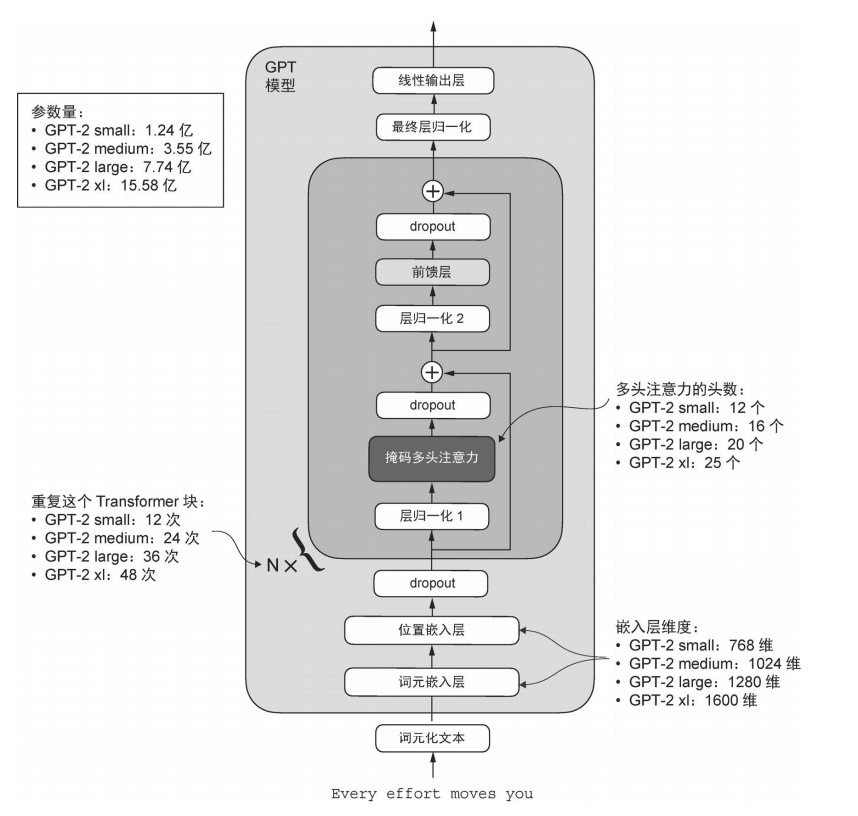

上面，我们已经将 124M GPT-2 模型的权重加载到了 Python 中，但我们仍然需要将这些权重传入我们的 GPTModel 实例中。

首先，我们初始化一个新的 GPTModel 实例。需要注意的是，原始的 GPT 模型在多头注意力模块的查询、键和值矩阵的线性层中使用了偏置向量，但这并不是必须的，也不推荐这样做；然而，为了能够正确加载权重，我们需要在实现中启用这些偏置向量，通过将 qkv_bias 设置为 True。
另外，我们还使用了原始 GPT-2 模型所使用的 1024 token 上下文长度。

In [63]:
model_configs = {  # 定义一个字典保存不同 GPT-2 模型的配置，以简化管理
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}


model_name = "gpt2-small (124M)"  # 选择一个模型名称，这里以 "gpt2-small (124M)" 为例

NEW_CONFIG = GPT_CONFIG_124M.copy() # 复制基础配置
NEW_CONFIG.update(model_configs[model_name])  # 更新为所选模型的配置
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True}) # 设置上下文长度和启用 qkv_bias

# 使用更新后的配置实例化模型，并设置为评估模式
gpt = GPTModel(NEW_CONFIG) # 创建 GPT 模型实例
gpt.eval(); # 切换模型为评估模式（禁用 dropout 等）

接下来将 OpenAI 的权重分配到我们 GPTModel 实例中对应的权重张量。

In [59]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

In [60]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])
    
    
load_weights_into_gpt(gpt, params)
gpt.to(device);

如果模型加载正确，我们可以使用之前的 generate 函数来生成新文本。

In [61]:
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you toward more efficient and efficient processes, like in the car's oil and gas operation," the study said. To see if that
